In [7]:
import pandas as pd
import pyodbc

# Step 1: Create connection
try:
    conn = pyodbc.connect(
        "DRIVER={ODBC Driver 17 for SQL Server};"
        "SERVER=.\SQLEXPRESS;"
        "DATABASE=SupplyChain;"
        "Trusted_Connection=yes;"
    )
    print("✅ Connected to SQL Server successfully!")

except Exception as e:
    print("❌ Connection failed:", e)
    exit()

# Step 2: Write query
query = "SELECT * FROM Supplychain"

# Step 3: Load data into pandas
try:
    df = pd.read_sql(query, conn)
    print("✅ Data fetched successfully!\n")

    # Step 4: Show data
    print(df.head())

except Exception as e:
    print("❌ Error fetching data:", e)

# Step 5: Close connection
conn.close()


import numpy as np

print("\n📊 BASIC INFO")
print(df.info())

print("\n📌 FIRST 5 ROWS")
print(df.head())

print("\n📌 LAST 5 ROWS")
print(df.tail())

<>:8: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:8: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\rahul\AppData\Local\Temp\ipykernel_12508\3176378066.py:8: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  "SERVER=.\SQLEXPRESS;"
C:\Users\rahul\AppData\Local\Temp\ipykernel_12508\3176378066.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✅ Connected to SQL Server successfully!
✅ Data fetched successfully!

       Type  Days_for_shipping_(real)  Days_for_shipment_(scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit_per_order  Sales_per_customer   Delivery_Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category_Id   Category_Name Customer_City  ...  \
0                   0           73  Sporting Goods 

In [ ]:
!pip install pandas pyodbc matplotlib seaborn

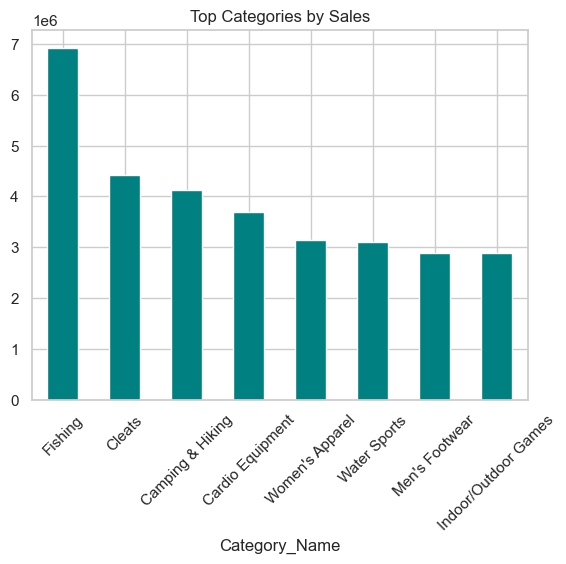

In [24]:
top_cat = df.groupby('Category_Name')['Sales'].sum().nlargest(8)

plt.figure()
top_cat.plot(kind='bar', color='teal')
plt.title("Top Categories by Sales")
plt.xticks(rotation=45)
plt.show()

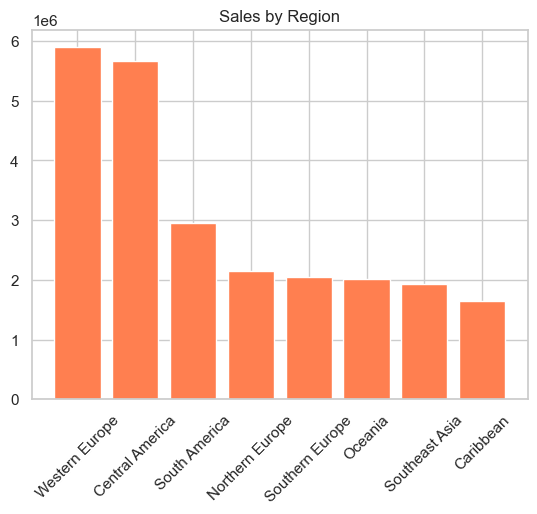

In [13]:
region_sales = df.groupby('Order_Region')['Sales'].sum().nlargest(8)

plt.figure()
plt.bar(region_sales.index, region_sales.values, color='coral')
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.show()

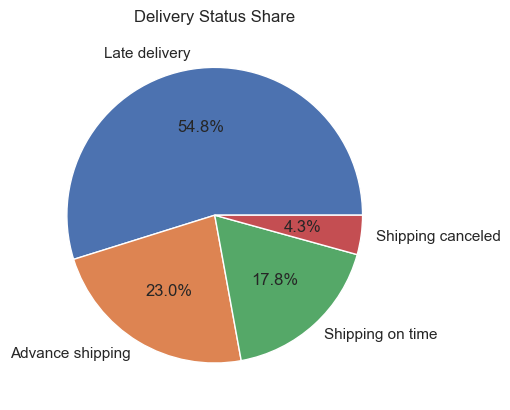

In [16]:
delivery_counts = df['Delivery_Status'].value_counts().head(5)

plt.figure()
plt.pie(delivery_counts, labels=delivery_counts.index, autopct='%1.1f%%')
plt.title("Delivery Status Share")
plt.show()

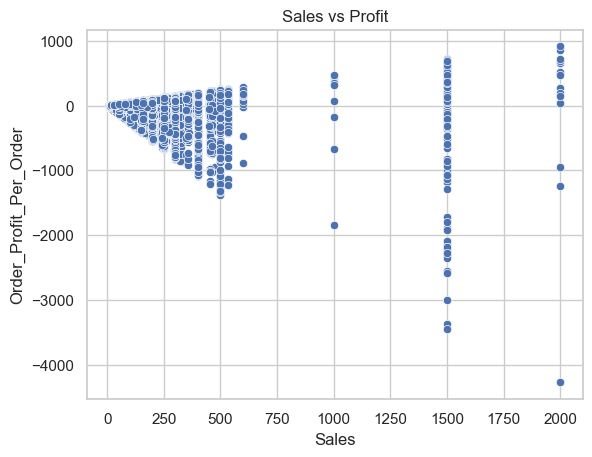

In [18]:
plt.figure()
sns.scatterplot(x='Sales', y='Order_Profit_Per_Order', data=df)
plt.title("Sales vs Profit")
plt.show()

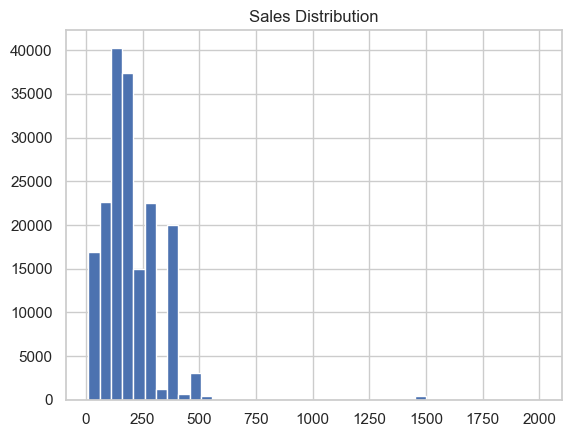

In [19]:
plt.figure()
plt.hist(df['Sales'], bins=40)
plt.title("Sales Distribution")
plt.show()

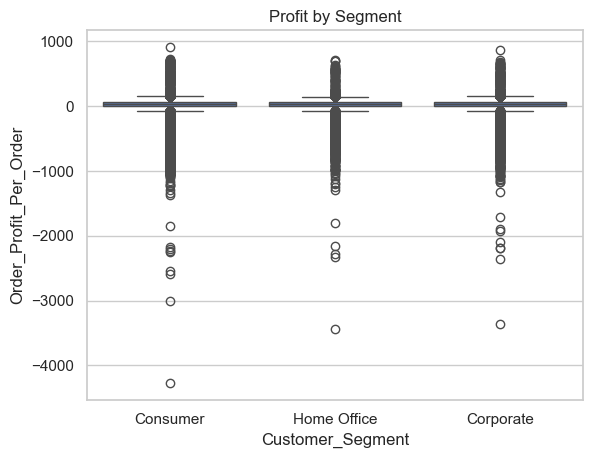

In [20]:
plt.figure()
sns.boxplot(x='Customer_Segment', y='Order_Profit_Per_Order', data=df)
plt.title("Profit by Segment")
plt.show()

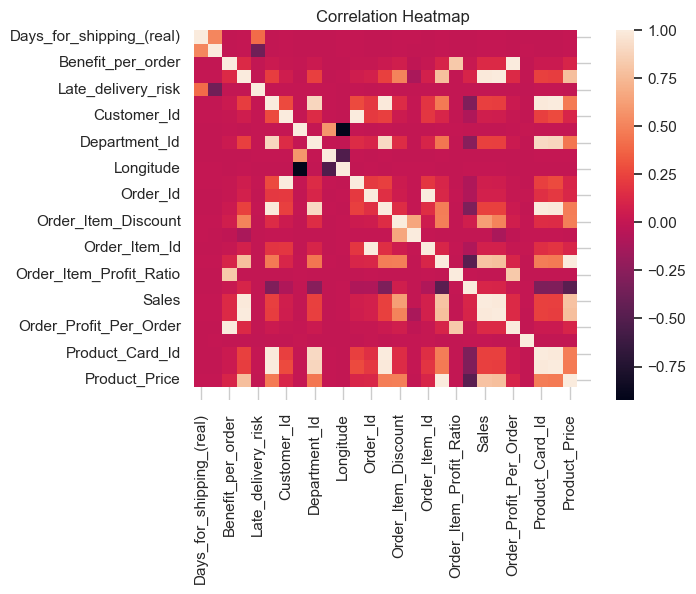

In [21]:
plt.figure()
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr)
plt.title("Correlation Heatmap")
plt.show()

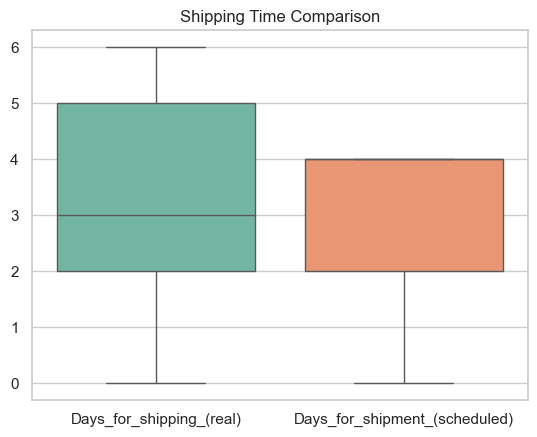

In [23]:
plt.figure()
sns.boxplot(data=df[['Days_for_shipping_(real)', 'Days_for_shipment_(scheduled)']], palette='Set2')
plt.title("Shipping Time Comparison")
plt.show()

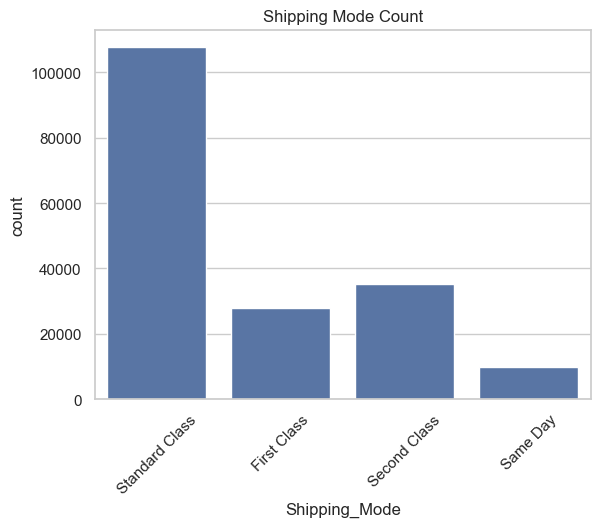

In [22]:
plt.figure()
sns.countplot(x='Shipping_Mode', data=df)
plt.xticks(rotation=45)
plt.title("Shipping Mode Count")
plt.show()